# San Diego County Coastal Water Quality: Time Series Analysis
### Locations South of Point Loma (Coronado, Silver Strand, Imperial Beach)

This notebook downloads the latest 2 weeks of San Diego County water quality data directly from the County DEHQ portal and plots time series across coastal monitoring stations from Point Loma south to the US-Mexico border.

Stations are organized into three primary coastal zones:
1. **Coronado Ocean Beaches**: **EH-060** (North Beach), **EH-050** (Main Tower), and **IB-079** (Avenida Lunar) grouped together
2. **Silver Strand & Tidelands**: **IB-068** (Guard Shack) and **EH-070** (Tidelands Park)
3. **Imperial Beach**: **IB-060** (Carnation Ave), **EH-030** (IB Pier), **EH-010** (Cortez Ave), and **IB-050** (End of Seacoast Dr)
*(Inner bay stations EH-090, EH-120, and EH-080 are excluded).*


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

# Import custom download function
from download_water_quality import download_sd_water_quality

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'Helvetica, Arial, DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8


## 1. Download Latest 2 Weeks of Water Quality Data
We call `download_sd_water_quality(days=14)` to fetch live data from the County of San Diego DEHQ portal and save it locally.


In [2]:
# Download water quality data for the last 14 days
csv_filename = "sd_water_quality_south_pt_loma.csv"
df = download_sd_water_quality(output_csv=csv_filename, days=14)

print(f"Total records loaded: {len(df)}")
df.head(5)


Connecting to County of San Diego DEHQ portal (cosdapps.sandiegocounty.gov/sdbeachinfo)...


Successfully retrieved 2000 records from County DEHQ portal.
Found 114 records matching criteria south of Pt. Loma.
Successfully saved data to 'sd_water_quality_south_pt_loma.csv'.
Total records loaded: 114


,id,Station_ID,Station Name,SampleDate,SampleTime,parameter,qualifier,Result,unit,method,type,County,Description,Status,Beach Name,Latitude,Longitude,CreateDate,Result_Numeric
0,5375,EH-120,EH-120,2026-09-02,08:31:00,Enterococcus,=,465,Copies/100ml,ddPCR,,San Diego,Bayside Park (J Street),,San Diego Bay,32.628802,-117.108094,2026-09-02,465
1,5376,IB-050,IB-050,2026-09-02,07:58:00,Enterococcus,=,5205,Copies/100ml,ddPCR,,San Diego,End of Seacoast Dr,,Imperial Beach Municipal Beach,32.566577,-117.133205,2026-09-02,5205
2,5377,EH-010,EH-010,2026-09-02,07:48:00,Enterococcus,=,2731,Copies/100ml,ddPCR,,San Diego,Cortez Ave,,Imperial Beach Municipal Beach,32.572665,-117.133201,2026-09-02,2731
3,5378,EH-030,EH-030,2026-09-02,07:40:00,Enterococcus,=,3735,Copies/100ml,ddPCR,,San Diego,Imperial Beach Pier,,Imperial Beach Municipal Beach,32.578750,-117.133186,2026-09-02,3735
4,5379,IB-060,IB-060,2026-09-02,07:30:00,Enterococcus,=,4251,Copies/100ml,ddPCR,,San Diego,Carnation Ave.,,Imperial Beach Municipal Beach,32.585679,-117.133049,2026-09-02,4251


## 2. Data Cleaning and Station Grouping
We parse timestamps, convert bacterial counts to numeric values, exclude inner bay stations (**EH-090**, **EH-120**, **EH-080**), and group the 3 Coronado ocean locations (**EH-060**, **EH-050**, **IB-079**) together.


In [3]:
# Combine SampleDate and SampleTime into a single datetime timestamp
def parse_datetime(row):
    time_str = str(row['SampleTime']).strip() if pd.notna(row['SampleTime']) else '12:00:00'
    if len(time_str) == 5:
        time_str += ':00'
    date_str = str(row['SampleDate']).split()[0]
    try:
        return pd.to_datetime(f"{date_str} {time_str}")
    except Exception:
        return pd.to_datetime(date_str)

df['Timestamp'] = df.apply(parse_datetime, axis=1)
df['Result_Numeric'] = pd.to_numeric(df['Result'], errors='coerce')
df['Latitude'] = pd.to_numeric(df['Latitude'], errors='coerce')
df['Longitude'] = pd.to_numeric(df['Longitude'], errors='coerce')

# Filter for Enterococcus ddPCR
ent_df = df[df['parameter'].str.contains('Enterococcus', case=False, na=False)].copy()

# Exclude requested inner bay stations
EXCLUDED_STATIONS = {'EH-090', 'EH-120', 'EH-080'}
ent_df = ent_df[~ent_df['Station Name'].isin(EXCLUDED_STATIONS)].copy()

# Group stations by coastal zone, ensuring the 3 Coronado ocean locations are grouped together first:
# 1. Coronado Ocean Beaches: EH-060, EH-050, IB-079
# 2. Silver Strand & Tidelands: IB-068, EH-070
# 3. Imperial Beach: IB-060, EH-030, EH-010, IB-050
station_order = [
    'EH-060',  # Coronado North Beach
    'EH-050',  # Coronado Main Lifeguard Tower
    'IB-079',  # Coronado Avenida Lunar
    'IB-068',  # Silver Strand Guard Shack
    'EH-070',  # Tidelands Park
    'IB-060',  # Carnation Ave (IB)
    'EH-030',  # Imperial Beach Pier
    'EH-010',  # Cortez Ave (IB)
    'IB-050',  # End of Seacoast Dr (IB)
]
station_order = [s for s in station_order if s in ent_df['Station Name'].values]

print(f"Active stations grouped for plotting ({len(station_order)} stations):")
for st in station_order:
    sub = ent_df[ent_df['Station Name'] == st]
    desc = sub['Description'].iloc[0] if len(sub) > 0 else ''
    beach = sub['Beach Name'].iloc[0] if len(sub) > 0 else ''
    lat = sub['Latitude'].iloc[0] if len(sub) > 0 else 0
    print(f"  {st:<8} ({lat:.4f}°N) - {desc} ({beach})")


Active stations grouped for plotting (9 stations):
  EH-060   (32.6856°N) - Coronado North Beach (Coronado City Beaches)
  EH-050   (32.6818°N) - Coronado Main Lifeguard Tower (Coronado City Beaches)
  IB-079   (32.6741°N) - Avenida Lunar (Coronado City Beaches)
  IB-068   (32.6264°N) - Silver Strand - Guard Shack (Silver Strand State Beach)
  EH-070   (32.6901°N) - Tidelands Park (San Diego Bay)
  IB-060   (32.5857°N) - Carnation Ave. (Imperial Beach Municipal Beach)
  EH-030   (32.5787°N) - Imperial Beach Pier (Imperial Beach Municipal Beach)
  EH-010   (32.5727°N) - Cortez Ave (Imperial Beach Municipal Beach)
  IB-050   (32.5666°N) - End of Seacoast Dr (Imperial Beach Municipal Beach)


## 3. Multi-Panel Time Series by Station
Individual time series for each of the 9 coastal stations.
- **Top Row**: The 3 Coronado ocean locations grouped together (**EH-060**, **EH-050**, **IB-079**).
- **Middle Row**: Silver Strand Guard Shack (**IB-068**), Tidelands Park (**EH-070**), and Carnation Ave (**IB-060**).
- **Bottom Row**: Imperial Beach Pier (**EH-030**), Cortez Ave (**EH-010**), and End of Seacoast Dr (**IB-050**).
- **Red dashed line**: California ddPCR Single-Sample Health Standard (**1,413 copies / 100 mL**).


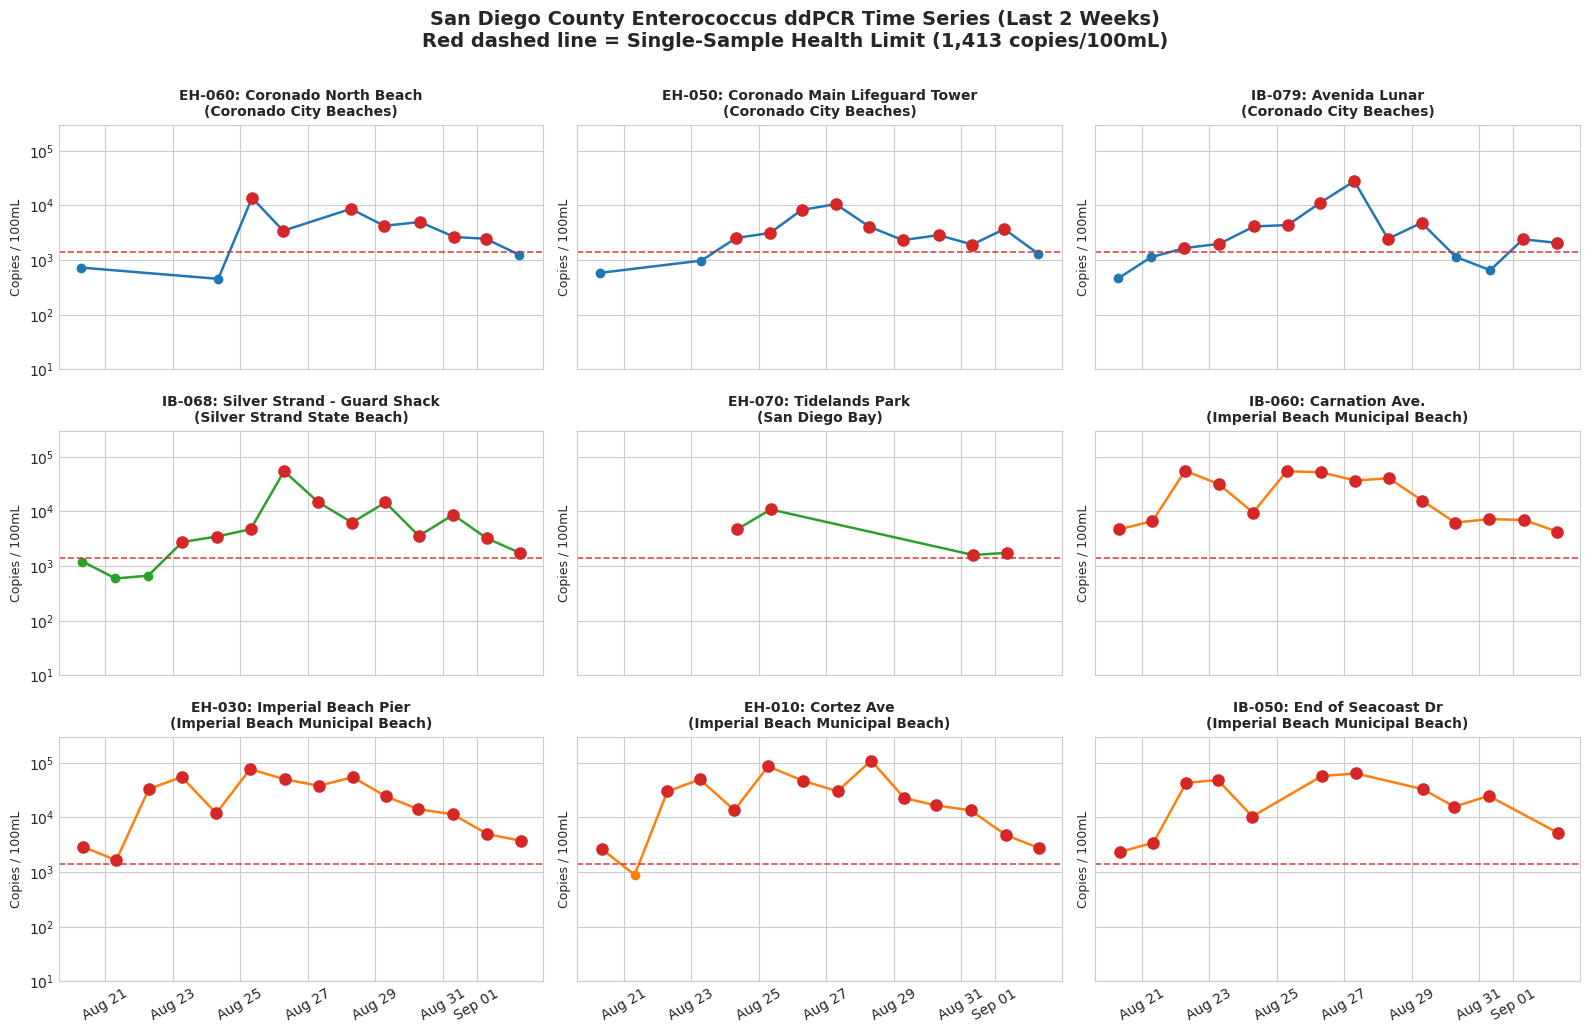

In [4]:
DDPCR_LIMIT = 1413  # copies / 100 mL

n_stations = len(station_order)
cols = 3
rows = int(np.ceil(n_stations / cols))

fig, axes = plt.subplots(rows, cols, figsize=(16, 3.4 * rows), sharex=True, sharey=True)
axes = axes.flatten()

for i, st in enumerate(station_order):
    ax = axes[i]
    st_data = ent_df[ent_df['Station Name'] == st].sort_values('Timestamp')
    desc = st_data['Description'].iloc[0] if len(st_data) > 0 else st
    beach = st_data['Beach Name'].iloc[0] if len(st_data) > 0 else ''
    
    # Highlight Coronado group in blue, others in distinct palette
    is_coronado = st in {'EH-060', 'EH-050', 'IB-079'}
    line_color = '#1f77b4' if is_coronado else '#2ca02c' if st in {'IB-068', 'EH-070'} else '#ff7f0e'
    
    # Plot concentration time series
    ax.plot(st_data['Timestamp'], st_data['Result_Numeric'], marker='o', color=line_color,
            linewidth=1.8, markersize=6, label='Enterococcus')
    
    # Highlight exceedances
    exceed = st_data[st_data['Result_Numeric'] >= DDPCR_LIMIT]
    if len(exceed) > 0:
        ax.scatter(exceed['Timestamp'], exceed['Result_Numeric'], color='#d62728',
                   s=65, zorder=5, label='Exceeds Limit')
    
    # Regulatory limit line
    ax.axhline(DDPCR_LIMIT, color='#d62728', linestyle='--', linewidth=1.2, alpha=0.85)
    
    title_str = f"{st}: {desc}"
    if beach:
        title_str += f"\n({beach})"
    ax.set_title(title_str, fontsize=10, fontweight='bold')
    ax.set_yscale('log')
    ax.set_ylim(10, 300000)
    ax.set_ylabel('Copies / 100mL', fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30)

# Remove any unused axes
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('San Diego County Enterococcus ddPCR Time Series (Last 2 Weeks)\n'
             f'Red dashed line = Single-Sample Health Limit ({DDPCR_LIMIT:,} copies/100mL)',
             fontsize=14, fontweight='bold', y=1.008)
plt.tight_layout()
plt.show()


## 4. Grouped Comparative Time Series by Coastal Zone
Comparing water quality across the coastal zones:
1. **Coronado Ocean Beaches**: **EH-060** (North Beach), **EH-050** (Main Tower), and **IB-079** (Avenida Lunar) grouped together on the top panel.
2. **Silver Strand & Tidelands**: **IB-068** (Guard Shack) and **EH-070** (Tidelands Park) on the middle panel.
3. **Imperial Beach**: **IB-060** (Carnation Ave), **EH-030** (IB Pier), **EH-010** (Cortez Ave), and **IB-050** (End of Seacoast Dr) on the bottom panel.


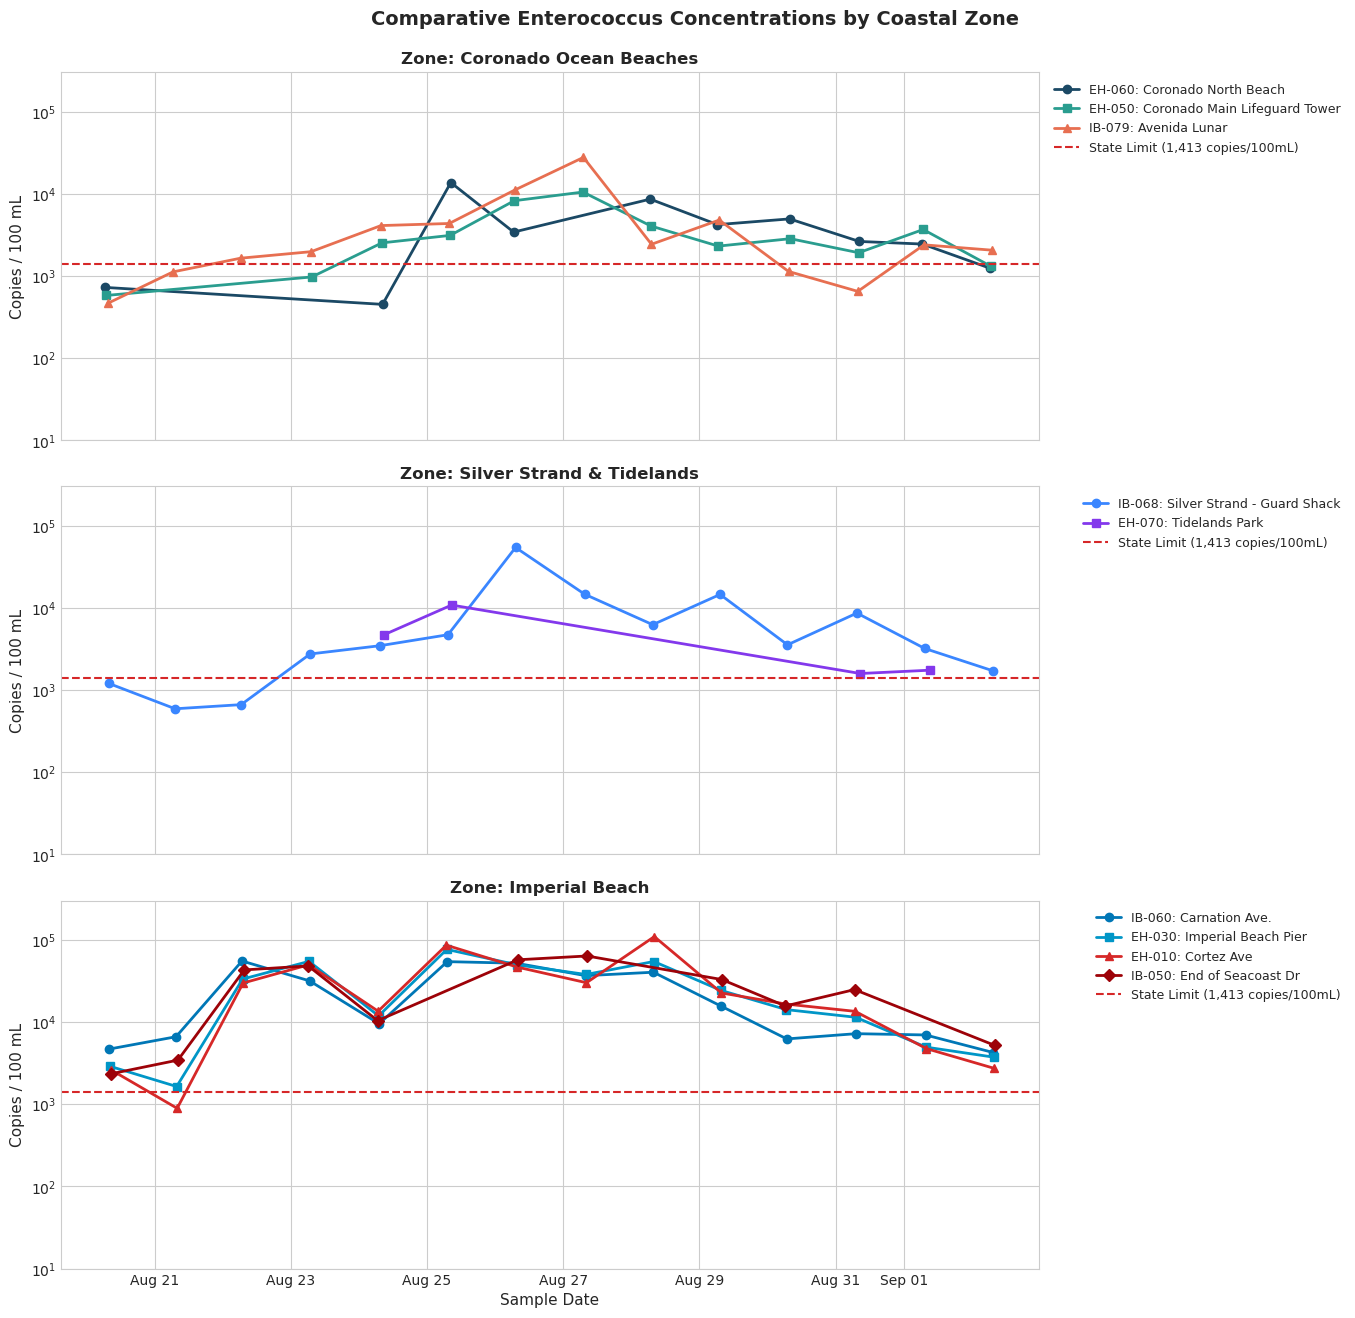

In [5]:
def get_coastal_zone(row):
    s = str(row['Station Name']).strip().upper()
    if s in {'EH-060', 'EH-050', 'IB-079'}:
        return 'Coronado Ocean Beaches'
    elif s in {'IB-068', 'EH-070'}:
        return 'Silver Strand & Tidelands'
    elif s in {'IB-060', 'EH-030', 'EH-010', 'IB-050'}:
        return 'Imperial Beach'
    return 'Other'

ent_df['Zone'] = ent_df.apply(get_coastal_zone, axis=1)

zones = ['Coronado Ocean Beaches', 'Silver Strand & Tidelands', 'Imperial Beach']
fig, axes = plt.subplots(len(zones), 1, figsize=(14, 4.4 * len(zones)), sharex=True)

# Distinct palettes and markers for each zone
zone_styles = {
    'Coronado Ocean Beaches': {
        'colors': ['#1b4965', '#2a9d8f', '#e76f51'],  # North Beach, Main Tower, Avenida Lunar
        'markers': ['o', 's', '^']
    },
    'Silver Strand & Tidelands': {
        'colors': ['#3a86ff', '#8338ec'],
        'markers': ['o', 's']
    },
    'Imperial Beach': {
        'colors': ['#0077b6', '#0096c7', '#d62828', '#9d0208'],
        'markers': ['o', 's', '^', 'D']
    }
}

for ax, zone in zip(axes, zones):
    zone_data = ent_df[ent_df['Zone'] == zone].sort_values('Timestamp')
    stations_in_zone = [s for s in station_order if s in zone_data['Station Name'].unique()]
    
    style = zone_styles.get(zone, {'colors': sns.color_palette('tab10', 10), 'markers': ['o']*10})
    
    for idx, st in enumerate(stations_in_zone):
        sub = zone_data[zone_data['Station Name'] == st]
        desc = sub['Description'].iloc[0] if len(sub) > 0 else st
        col = style['colors'][idx % len(style['colors'])]
        mk = style['markers'][idx % len(style['markers'])]
        
        ax.plot(sub['Timestamp'], sub['Result_Numeric'], marker=mk,
                label=f"{st}: {desc}", linewidth=2.0, markersize=6, color=col)
        
    ax.axhline(DDPCR_LIMIT, color='#d62728', linestyle='--', linewidth=1.5,
               label=f'State Limit ({DDPCR_LIMIT:,} copies/100mL)')
    ax.set_yscale('log')
    ax.set_ylim(10, 300000)
    ax.set_ylabel('Copies / 100 mL', fontsize=11)
    ax.set_title(f'Zone: {zone}', fontsize=12, fontweight='bold')
    ax.legend(loc='upper right', bbox_to_anchor=(1.32, 1.0), fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

axes[-1].set_xlabel('Sample Date', fontsize=11)
fig.suptitle('Comparative Enterococcus Concentrations by Coastal Zone', fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()


## 5. Alongshore Space-Time (Hovmöller) Diagram
Latitude vs. Date plot illustrating alongshore bacterial distribution and northward advective signals from Imperial Beach through Silver Strand to Coronado.


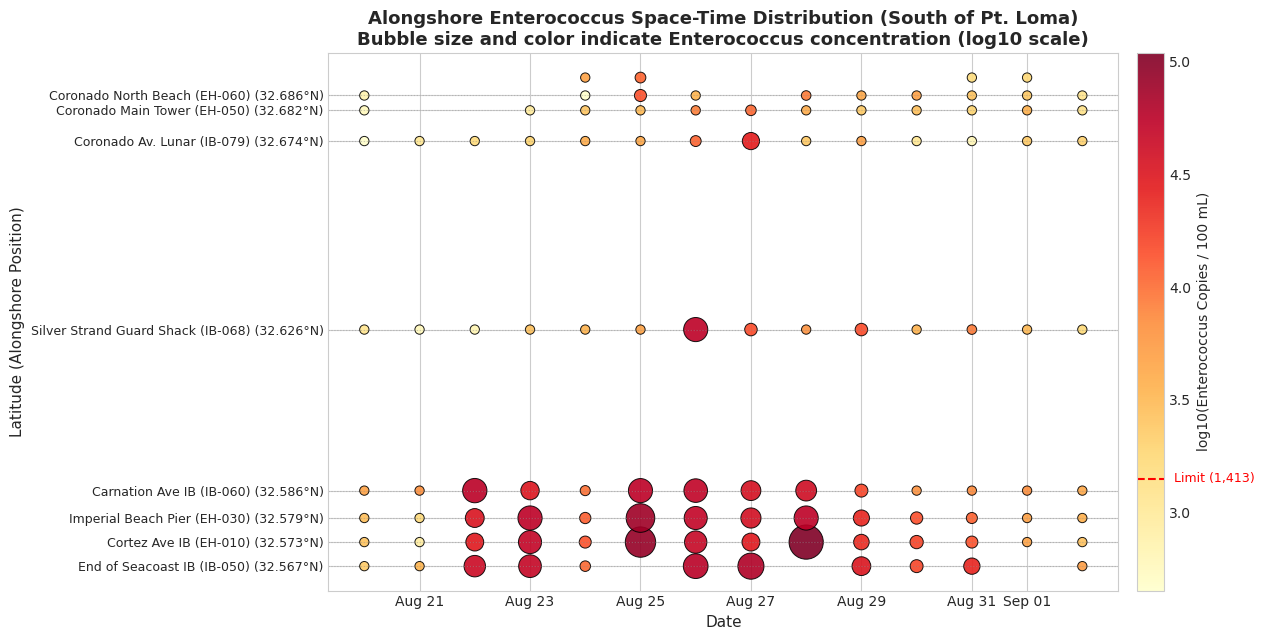

In [6]:
# Aggregate daily maximum concentration per station
daily_st = ent_df.groupby([ent_df['Timestamp'].dt.date, 'Station Name', 'Latitude', 'Description'])['Result_Numeric'].max().reset_index()
daily_st.rename(columns={'Timestamp': 'Date'}, inplace=True)
daily_st['Date'] = pd.to_datetime(daily_st['Date'])

plt.figure(figsize=(13, 6.5))

scatter = plt.scatter(
    daily_st['Date'],
    daily_st['Latitude'],
    c=np.log10(np.maximum(daily_st['Result_Numeric'], 1)),
    s=np.clip(daily_st['Result_Numeric'] / 180, 45, 650),
    cmap='YlOrRd',
    edgecolors='black',
    linewidth=0.7,
    alpha=0.9
)

landmarks = {
    32.6856: 'Coronado North Beach (EH-060)',
    32.6818: 'Coronado Main Tower (EH-050)',
    32.6741: 'Coronado Av. Lunar (IB-079)',
    32.6264: 'Silver Strand Guard Shack (IB-068)',
    32.5857: 'Carnation Ave IB (IB-060)',
    32.5787: 'Imperial Beach Pier (EH-030)',
    32.5727: 'Cortez Ave IB (EH-010)',
    32.5666: 'End of Seacoast IB (IB-050)'
}

for lat_val, name in landmarks.items():
    plt.axhline(lat_val, color='#999999', linestyle=':', linewidth=0.8, alpha=0.5)

plt.yticks(list(landmarks.keys()), [f"{name} ({lat:.3f}°N)" for lat, name in landmarks.items()], fontsize=9)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xlabel('Date', fontsize=11)
plt.ylabel('Latitude (Alongshore Position)', fontsize=11)
plt.title('Alongshore Enterococcus Space-Time Distribution (South of Pt. Loma)\n'
          'Bubble size and color indicate Enterococcus concentration (log10 scale)', fontsize=13, fontweight='bold')

cbar = plt.colorbar(scatter, pad=0.02)
cbar.set_label('log10(Enterococcus Copies / 100 mL)', fontsize=10)

cbar_limit = np.log10(DDPCR_LIMIT)
cbar.ax.axhline(cbar_limit, color='red', linestyle='--', linewidth=1.5)
cbar.ax.text(1.2, cbar_limit, f' Limit ({DDPCR_LIMIT:,})', color='red', va='center', fontsize=9)

plt.tight_layout()
plt.show()


## 6. Station Summary & Exceedance Table
Summary metrics for each coastal station over the 2-week monitoring period.


In [7]:
summary_stats = []

for st in station_order:
    sub = ent_df[ent_df['Station Name'] == st].sort_values('Timestamp')
    if len(sub) == 0:
        continue
    
    desc = sub['Description'].iloc[0]
    beach = sub['Beach Name'].iloc[0]
    lat = sub['Latitude'].iloc[0]
    latest_val = sub['Result_Numeric'].iloc[-1]
    latest_date = sub['Timestamp'].iloc[-1].strftime('%Y-%m-%d')
    max_val = sub['Result_Numeric'].max()
    geom_mean = np.exp(np.log(np.maximum(sub['Result_Numeric'], 1)).mean())
    n_samples = len(sub)
    n_exceed = (sub['Result_Numeric'] >= DDPCR_LIMIT).sum()
    pct_exceed = (n_exceed / n_samples) * 100
    
    summary_stats.append({
        'Station': st,
        'Description': desc,
        'Beach / Area': beach,
        'Latitude': f"{lat:.4f}",
        'Samples': n_samples,
        'Latest (Copies/100ml)': f"{latest_val:,.0f} ({latest_date})",
        'Max (Copies/100ml)': f"{max_val:,.0f}",
        'Geom. Mean': f"{geom_mean:,.0f}",
        'Exceedances (>1413)': f"{n_exceed}/{n_samples} ({pct_exceed:.0f}%)"
    })

summary_df = pd.DataFrame(summary_stats)
summary_df


,Station,Description,Beach / Area,Latitude,Samples,Latest (Copies/100ml),Max (Copies/100ml),Geom. Mean,Exceedances (>1413)
0,EH-060,Coronado North Beach,Coronado City Beaches,32.6856,10,"1,236 (2026-09-02)","13,681","2,714",7/10 (70%)
1,EH-050,Coronado Main Lifeguard Tower,Coronado City Beaches,32.6818,12,"1,305 (2026-09-02)","10,487","2,594",9/12 (75%)
2,IB-079,Avenida Lunar,Coronado City Beaches,32.6741,14,"2,059 (2026-09-02)","27,680","2,507",10/14 (71%)
3,IB-068,Silver Strand - Guard Shack,Silver Strand State Beach,32.6264,14,"1,722 (2026-09-02)","54,298","3,992",11/14 (79%)
4,EH-070,Tidelands Park,San Diego Bay,32.6901,4,"1,744 (2026-09-01)","10,821","3,444",4/4 (100%)
5,IB-060,Carnation Ave.,Imperial Beach Municipal Beach,32.5857,14,"4,251 (2026-09-02)","55,212","15,465",14/14 (100%)
6,EH-030,Imperial Beach Pier,Imperial Beach Municipal Beach,32.5787,14,"3,735 (2026-09-02)","76,440","15,755",14/14 (100%)
7,EH-010,Cortez Ave,Imperial Beach Municipal Beach,32.5727,14,"2,731 (2026-09-02)","109,373","15,349",13/14 (93%)
8,IB-050,End of Seacoast Dr,Imperial Beach Municipal Beach,32.5666,11,"5,205 (2026-09-02)","63,584","17,310",11/11 (100%)
